In [2]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import sys
from collections import defaultdict

import gc
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix
seed = 9001
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

2026-05-06 14:23:08.897833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778077389.288029      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778077389.394744      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778077390.338760      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778077390.338804      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778077390.338807      57 computation_placer.cc:177] computation placer alr

In [4]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val"

X_train = np.load(os.path.join(INPUT_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(INPUT_PATH, 'y_train.npy'))
id_train = np.load(os.path.join(INPUT_PATH, 'id_train.npy'), allow_pickle=True)

X_val = np.load(os.path.join(INPUT_PATH, 'X_val.npy'))
y_val = np.load(os.path.join(INPUT_PATH, 'y_val.npy'))
id_val = np.load(os.path.join(INPUT_PATH, 'id_val.npy'), allow_pickle=True)

X_test = np.load(os.path.join(INPUT_PATH, 'X_test.npy'))
y_test = np.load(os.path.join(INPUT_PATH, 'y_test.npy'))
id_test = np.load(os.path.join(INPUT_PATH, 'id_test.npy'), allow_pickle=True)

In [5]:
print("Train:", X_train.shape, y_train.shape, id_train.shape)
print("Val  :", X_val.shape, y_val.shape, id_val.shape)
print("Test :", X_test.shape, y_test.shape, id_test.shape)

print("Unique train patients:", len(np.unique(id_train)))
print("Unique val patients  :", len(np.unique(id_val)))
print("Unique test patients :", len(np.unique(id_test)))

Train: (145772, 10, 133) (145772,) (145772,)
Val  : (36597, 10, 133) (36597,) (36597,)
Test : (45552, 10, 133) (45552,) (45552,)
Unique train patients: 25456
Unique val patients  : 6352
Unique test patients : 7964


In [6]:
X_train = np.asarray(X_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
X_test  = np.asarray(X_test).astype(np.float32)

y_train = np.asarray(y_train).astype(np.int32).reshape(-1)
y_val   = np.asarray(y_val).astype(np.int32).reshape(-1)
y_test  = np.asarray(y_test).astype(np.int32).reshape(-1)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("y_val:  ", y_val.shape, y_val.dtype)
print("X_test: ", X_test.shape, X_test.dtype)
print("y_test: ", y_test.shape, y_test.dtype)

assert X_train.ndim == 3, f"X_train phải là 3D, hiện tại là {X_train.ndim}D"
assert X_val.ndim == 3, f"X_val phải là 3D, hiện tại là {X_val.ndim}D"
assert X_test.ndim == 3, f"X_test phải là 3D, hiện tại là {X_test.ndim}D"

assert len(X_train) == len(y_train), "X_train và y_train lệch số mẫu"
assert len(X_val) == len(y_val), "X_val và y_val lệch số mẫu"
assert len(X_test) == len(y_test), "X_test và y_test lệch số mẫu"

print("timesteps =", X_train.shape[1])
print("n_features =", X_train.shape[2])
print("Train class distribution:", np.bincount(y_train))
print("Val class distribution:", np.bincount(y_val))
print("Test class distribution:", np.bincount(y_test))

X_train: (145772, 10, 133) float32
y_train: (145772,) int32
X_val:   (36597, 10, 133) float32
y_val:   (36597,) int32
X_test:  (45552, 10, 133) float32
y_test:  (45552,) int32
timesteps = 10
n_features = 133
Train class distribution: [134796  10976]
Val class distribution: [33804  2793]
Test class distribution: [42337  3215]


In [7]:
MODULE_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-utils"
if MODULE_PATH not in sys.path:
    sys.path.append(MODULE_PATH)

from model_utils import (
    create_bilstm,
    get_callbacks,
    find_best_threshold,
    full_evaluation,
)

In [8]:
# Create a separate search-validation split from the training set
SEARCH_VAL_FRAC = 0.15
SEARCH_SPLIT_SEED = 2026

gss_search = GroupShuffleSplit(
    n_splits=1,
    test_size=SEARCH_VAL_FRAC,
    random_state=SEARCH_SPLIT_SEED
)

search_train_idx, search_val_idx = next(
    gss_search.split(X_train, y_train, groups=id_train)
)

X_search_train = X_train[search_train_idx]
y_search_train = y_train[search_train_idx]
id_search_train = id_train[search_train_idx]

X_search_val = X_train[search_val_idx]
y_search_val = y_train[search_val_idx]
id_search_val = id_train[search_val_idx]

print("SEARCH TRAIN:", X_search_train.shape, y_search_train.shape, len(np.unique(id_search_train)), "patients")
print("SEARCH VAL  :", X_search_val.shape, y_search_val.shape, len(np.unique(id_search_val)), "patients")

# Build patient-level labels for the search split
search_patient_labels = defaultdict(int)
for pid, y in zip(id_search_train, y_search_train):
    search_patient_labels[pid] = max(search_patient_labels[pid], int(y))

search_train_patient_ids = np.array(sorted(search_patient_labels.keys()))
search_pos_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 1])
search_neg_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 0])

print("SEARCH train patients:", len(search_train_patient_ids))
print("SEARCH positive patients:", len(search_pos_patients))
print("SEARCH negative patients:", len(search_neg_patients))

SEARCH TRAIN: (124113, 10, 133) (124113,) 21637 patients
SEARCH VAL  : (21659, 10, 133) (21659,) 3819 patients
SEARCH train patients: 21637
SEARCH positive patients: 1415
SEARCH negative patients: 20222


### FIND HYPERPARAMETERS FOR ENSEMBLE

In [9]:
# Hyperparameter search configuration

# Focus on the range that showed good performance in previous runs
CANDIDATES = [
    {"units": 16,  "dropout": 0.3, "batch_size": 512},
    {"units": 16,  "dropout": 0.5, "batch_size": 512},
    {"units": 32,  "dropout": 0.3, "batch_size": 512},
    {"units": 32,  "dropout": 0.5, "batch_size": 512},
    {"units": 64,  "dropout": 0.4, "batch_size": 256},
]

# Use a lighter search setup to reduce runtime:
# - use SEARCH_N_MODELS = 3 during the search phase
# - use 5 OUTER_SUBSET_SEEDS for a more stable mean estimate
OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS = 3
SEARCH_SEEDS = [42, 52, 62]

# Use separate epoch settings for search and final training
SEARCH_EPOCHS = 40
EPOCHS = 50

# Final ensemble configuration
N_MODELS = 5
SEEDS = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC = 0.9

# These values will be set after hyperparameter search
BEST_UNITS = None
BEST_DROPOUT = None
BEST_BATCH_SIZE = None

print("Hyperparameter search config loaded.")
print("Candidates:")
for cfg in CANDIDATES:
    print(cfg)

print("\nOUTER_SUBSET_SEEDS =", OUTER_SUBSET_SEEDS)
print("SEARCH_N_MODELS     =", SEARCH_N_MODELS)
print("SEARCH_SEEDS        =", SEARCH_SEEDS)
print("SEARCH_EPOCHS       =", SEARCH_EPOCHS)
print("EPOCHS (final)      =", EPOCHS)
print("N_MODELS (final)    =", N_MODELS)
print("SEEDS (final)       =", SEEDS)
print("NEG_SUBSET_FRAC     =", NEG_SUBSET_FRAC)

Hyperparameter search config loaded.
Candidates:
{'units': 16, 'dropout': 0.3, 'batch_size': 512}
{'units': 16, 'dropout': 0.5, 'batch_size': 512}
{'units': 32, 'dropout': 0.3, 'batch_size': 512}
{'units': 32, 'dropout': 0.5, 'batch_size': 512}
{'units': 64, 'dropout': 0.4, 'batch_size': 256}

OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS     = 3
SEARCH_SEEDS        = [42, 52, 62]
SEARCH_EPOCHS       = 40
EPOCHS (final)      = 50
N_MODELS (final)    = 5
SEEDS (final)       = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC     = 0.9


In [10]:
PATIENT_SUBSET_SEED = 42

assert len(SEEDS) == N_MODELS, "SEEDS và N_MODELS phải khớp nhau"

# patient-level label 
# Treat a patient as positive if at least one sequence label is positive.
patient_labels = defaultdict(int)

for pid, y in zip(id_train, y_train):
    patient_labels[pid] = max(patient_labels[pid], int(y))

train_patient_ids = np.array(sorted(patient_labels.keys()))
pos_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 1])
neg_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 0])

print("Total train patients:", len(train_patient_ids))
print("Positive patients   :", len(pos_patients))
print("Negative patients   :", len(neg_patients))

def make_patient_subsets_all_pos(
    pos_patients,
    neg_patients,
    n_models=5,
    neg_frac=0.9,
    seed=42
):
    subsets = []
    neg_counts = []

    n_neg = max(1, int(len(neg_patients) * neg_frac))

    for i in range(n_models):
        rng = np.random.default_rng(seed + i)

        sub_pos = np.array(pos_patients, copy=True)
        sub_neg = rng.choice(neg_patients, size=n_neg, replace=False)

        subset_ids = np.concatenate([sub_pos, sub_neg])
        rng.shuffle(subset_ids)

        subsets.append(subset_ids)
        neg_counts.append(len(sub_neg))

    return subsets, n_neg, neg_counts

patient_subsets, n_neg_per_member, neg_counts = make_patient_subsets_all_pos(
    pos_patients=pos_patients,
    neg_patients=neg_patients,
    n_models=N_MODELS,
    neg_frac=NEG_SUBSET_FRAC,
    seed=PATIENT_SUBSET_SEED
)

print(f"- Subset only negative patients with NEG_SUBSET_FRAC = {NEG_SUBSET_FRAC}")
print(f"- Negative patients per member = {n_neg_per_member}")

for i, subset_ids in enumerate(patient_subsets):
    unique_ids = np.unique(subset_ids)
    n_pos_in_subset = np.intersect1d(unique_ids, pos_patients).size
    n_neg_in_subset = np.intersect1d(unique_ids, neg_patients).size
    print(
        f"Model {i+1}: total={len(unique_ids)} patients | "
        f"pos={n_pos_in_subset} | neg={n_neg_in_subset}"
    )

Total train patients: 25456
Positive patients   : 1650
Negative patients   : 23806
- Subset only negative patients with NEG_SUBSET_FRAC = 0.9
- Negative patients per member = 21425
Model 1: total=23075 patients | pos=1650 | neg=21425
Model 2: total=23075 patients | pos=1650 | neg=21425
Model 3: total=23075 patients | pos=1650 | neg=21425
Model 4: total=23075 patients | pos=1650 | neg=21425
Model 5: total=23075 patients | pos=1650 | neg=21425


In [11]:
def run_full_ensemble_val_search_for_config(cfg):
    """
    Repeated full-ensemble validation search
    - use SEARCH split only
    - do not use X_val / X_test
    - use a lighter search setup than the final setup to save compute
    """
    
    outer_rows = []

    for outer_subset_seed in OUTER_SUBSET_SEEDS:
        print("\n" + "="*90)
        print(
            f"FULL SEARCH | units={cfg['units']} | "
            f"dropout={cfg['dropout']} | batch={cfg['batch_size']} | "
            f"outer_subset_seed={outer_subset_seed}"
        )
        print("="*90)

        search_patient_subsets, _, _ = make_patient_subsets_all_pos(
            pos_patients=search_pos_patients,
            neg_patients=search_neg_patients,
            n_models=SEARCH_N_MODELS,
            neg_frac=NEG_SUBSET_FRAC,
            seed=outer_subset_seed
        )

        val_probs_list = []
        member_rows = []

        for member_idx, seed in enumerate(SEARCH_SEEDS, start=1):
            print("\n" + "-"*70)
            print(f"SEARCH MEMBER {member_idx}/{SEARCH_N_MODELS} | seed={seed}")
            print("-"*70)

            K.clear_session()
            tf.keras.utils.set_random_seed(seed)

            subset_patient_ids = search_patient_subsets[member_idx - 1]
            train_mask = np.isin(id_search_train, subset_patient_ids)

            X_train_sub = X_search_train[train_mask]
            y_train_sub = y_search_train[train_mask]
            id_train_sub = id_search_train[train_mask]

            unique_subset_ids = np.unique(id_train_sub)
            n_pos_subset = np.intersect1d(unique_subset_ids, search_pos_patients).size
            n_neg_subset = np.intersect1d(unique_subset_ids, search_neg_patients).size

            print(f"Subset patients : {len(unique_subset_ids)}")
            print(f"  - positive patients kept : {n_pos_subset}/{len(search_pos_patients)}")
            print(f"  - negative patients used : {n_neg_subset}/{len(search_neg_patients)}")
            print(f"Subset samples  : {len(X_train_sub)}")
            print(f"Positive rate   : {y_train_sub.mean():.6f}")

            subset_classes = np.unique(y_train_sub)
            subset_class_weights = compute_class_weight(
                class_weight='balanced',
                classes=subset_classes,
                y=y_train_sub
            )
            class_weights_dict_sub = {
                int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
            }

            model = create_bilstm(
                n_units=cfg["units"],
                dropout=cfg["dropout"],
                seq_len=X_train.shape[1],
                n_features=X_train.shape[2],
                lr=1e-3
            )

            ckpt_path = (
                f"/kaggle/working/search_u{cfg['units']}_d{cfg['dropout']}_"
                f"b{cfg['batch_size']}_outer{outer_subset_seed}_member{member_idx}.keras"
            )
            callbacks = get_callbacks(
                checkpoint_path=ckpt_path,
                monitor='val_auprc'
            )

            history = model.fit(
                X_train_sub, y_train_sub,
                validation_data=(X_search_val, y_search_val),
                epochs=SEARCH_EPOCHS,
                batch_size=cfg["batch_size"],
                class_weight=class_weights_dict_sub,
                shuffle=True,
                callbacks=callbacks,
                verbose=0
            )

            # FIX: load best checkpoint trước khi predict
            model.load_weights(ckpt_path)
            val_prob = model.predict(X_search_val, verbose=0).ravel()
            val_probs_list.append(val_prob)

            if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
                best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
                best_idx = best_epoch - 1
                member_val_auprc = float(history.history["val_auprc"][best_idx])
                member_val_auroc = float(history.history["val_auroc"][best_idx])
            else:
                member_val_auprc = average_precision_score(y_search_val, val_prob)
                member_val_auroc = roc_auc_score(y_search_val, val_prob)

            print(f"member best val AUROC={member_val_auroc:.4f} | best val AUPRC={member_val_auprc:.4f}")

            member_rows.append({
                "member": member_idx,
                "val_auprc": member_val_auprc,
                "val_auroc": member_val_auroc
            })

            del model, history, X_train_sub, y_train_sub, id_train_sub
            gc.collect()

        val_probs_array = np.vstack(val_probs_list)
        df_members_local = pd.DataFrame(member_rows)

        member_weights = df_members_local["val_auprc"].to_numpy(dtype=float)
        if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
            member_weights = np.ones(len(df_members_local), dtype=float)
        member_weights = member_weights / member_weights.sum()

        ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
        ensemble_val_auprc = average_precision_score(y_search_val, ensemble_val_prob)
        ensemble_val_auroc = roc_auc_score(y_search_val, ensemble_val_prob)

        print("\n>>> SEARCH VALIDATION RESULT")
        print(f"Ensemble search-val AUROC : {ensemble_val_auroc:.4f}")
        print(f"Ensemble search-val AUPRC : {ensemble_val_auprc:.4f}")

        outer_rows.append({
            "units": cfg["units"],
            "dropout": cfg["dropout"],
            "batch_size": cfg["batch_size"],
            "outer_subset_seed": outer_subset_seed,
            "ensemble_val_auprc": float(ensemble_val_auprc),
            "ensemble_val_auroc": float(ensemble_val_auroc),
        })

    return pd.DataFrame(outer_rows)

In [12]:
all_search_runs = []

for cfg in CANDIDATES:
    df_cfg = run_full_ensemble_val_search_for_config(cfg)
    all_search_runs.append(df_cfg)

df_full_search_runs = pd.concat(all_search_runs, ignore_index=True)

summary = (
    df_full_search_runs
    .groupby(["units", "dropout", "batch_size"], as_index=False)
    .agg(
        mean_ensemble_val_auprc=("ensemble_val_auprc", "mean"),
        std_ensemble_val_auprc=("ensemble_val_auprc", "std"),
        mean_ensemble_val_auroc=("ensemble_val_auroc", "mean"),
        std_ensemble_val_auroc=("ensemble_val_auroc", "std"),
        n_runs=("ensemble_val_auprc", "count"),
    )
)

summary["std_ensemble_val_auprc"] = summary["std_ensemble_val_auprc"].fillna(0.0)
summary["std_ensemble_val_auroc"] = summary["std_ensemble_val_auroc"].fillna(0.0)

# Main metric: AUPRC, followed by standard deviation, then AUROC

summary = summary.sort_values(
    by=["mean_ensemble_val_auprc", "std_ensemble_val_auprc", "mean_ensemble_val_auroc"],
    ascending=[False, True, False]
).reset_index(drop=True)

best_cfg = summary.iloc[0].to_dict()

BEST_UNITS = int(best_cfg["units"])
BEST_DROPOUT = float(best_cfg["dropout"])
BEST_BATCH_SIZE = int(best_cfg["batch_size"])

print("\n=== FULL SEARCH RUNS ===")
print(df_full_search_runs)

print("\n=== SEARCH SUMMARY ===")
print(summary)

print("\n=== CHOSEN BEST CONFIG ===")
print(f"BEST_UNITS      = {BEST_UNITS}")
print(f"BEST_DROPOUT    = {BEST_DROPOUT}")
print(f"BEST_BATCH_SIZE = {BEST_BATCH_SIZE}")


FULL SEARCH | units=16 | dropout=0.3 | batch=512 | outer_subset_seed=42

----------------------------------------------------------------------
SEARCH MEMBER 1/3 | seed=42
----------------------------------------------------------------------
Subset patients : 19614
  - positive patients kept : 1415/1415
  - negative patients used : 18199/20222
Subset samples  : 113708
Positive rate   : 0.083407


I0000 00:00:1778077447.369801      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778077447.375678      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1778077456.127209     133 cuda_dnn.cc:529] Loaded cuDNN version 91002



Epoch 1: val_auprc improved from -inf to 0.26393, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 2: val_auprc improved from 0.26393 to 0.30706, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 3: val_auprc improved from 0.30706 to 0.33462, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 4: val_auprc improved from 0.33462 to 0.35330, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 5: val_auprc did not improve from 0.35330

Epoch 6: val_auprc improved from 0.35330 to 0.35593, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 7: val_auprc did not improve from 0.35593

Epoch 8: val_auprc did not improve from 0.35593

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_auprc did not improve from 0.35593

Epoch 10: val_auprc did not improve from 0.35593

Epoch 11: val_auprc did not improv

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.28125, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 2: val_auprc improved from 0.28125 to 0.32441, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 3: val_auprc improved from 0.32441 to 0.35188, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 4: val_auprc improved from 0.35188 to 0.36946, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 5: val_auprc did not improve from 0.36946

Epoch 6: val_auprc did not improve from 0.36946

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_auprc did not improve from 0.36946

Epoch 8: val_auprc did not improve from 0.36946

Epoch 9: val_auprc did not improve from 0.36946

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_auprc did not improve from 0.36946

Epoch 11: val_auprc did not improve 

...


Epoch 1: val_auprc improved from -inf to 0.34721, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member1.keras

Epoch 2: val_auprc improved from 0.34721 to 0.38990, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member1.keras

Epoch 3: val_auprc did not improve from 0.38990

Epoch 4: val_auprc did not improve from 0.38990

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auprc did not improve from 0.38990

Epoch 6: val_auprc did not improve from 0.38990

Epoch 7: val_auprc did not improve from 0.38990

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_auprc did not improve from 0.38990

Epoch 9: val_auprc did not improve from 0.38990

Epoch 10: val_auprc did not improve from 0.38990
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
member best val AUROC=0.8581 | best val AUPRC=0.3899

------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.34914, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member2.keras

Epoch 2: val_auprc improved from 0.34914 to 0.36173, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member2.keras

Epoch 3: val_auprc improved from 0.36173 to 0.36911, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member2.keras

Epoch 4: val_auprc did not improve from 0.36911

Epoch 5: val_auprc did not improve from 0.36911

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_auprc did not improve from 0.36911

Epoch 7: val_auprc did not improve from 0.36911

Epoch 8: val_auprc did not improve from 0.36911

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_auprc did not improve from 0.36911

Epoch 10: val_auprc did not improve from 0.36911

Epoch 11: val_auprc did not improve from 0.36911
Epoch 11: early stopping
Restoring model weights from the end of the

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.34553, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member3.keras

Epoch 2: val_auprc improved from 0.34553 to 0.41491, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member3.keras

Epoch 3: val_auprc did not improve from 0.41491

Epoch 4: val_auprc did not improve from 0.41491

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auprc did not improve from 0.41491

Epoch 6: val_auprc did not improve from 0.41491

Epoch 7: val_auprc did not improve from 0.41491

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_auprc did not improve from 0.41491

Epoch 9: val_auprc did not improve from 0.41491

Epoch 10: val_auprc did not improve from 0.41491
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
member best val AUROC=0.8530 | best val AUPRC=0.4149

>>> SEARCH VALIDATION RESULT
Ensemble search-val AUROC : 0.8

### TRAIN ENSEMBLE MEMBERS

In [13]:
val_probs_list = []
test_probs_list = []
member_summaries = []

for member_idx, seed in enumerate(SEEDS, start=1):
    print("\n" + "="*70)
    print(f"TRAINING ENSEMBLE MEMBER {member_idx}/{N_MODELS} | seed={seed}")
    print("="*70)

    K.clear_session()
    tf.keras.utils.set_random_seed(seed)

    # 1) Get the patient subset for the current member
    subset_patient_ids = patient_subsets[member_idx - 1]

    train_mask = np.isin(id_train, subset_patient_ids)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]
    id_train_sub = id_train[train_mask]

    unique_subset_ids = np.unique(id_train_sub)
    n_pos_subset = np.intersect1d(unique_subset_ids, pos_patients).size
    n_neg_subset = np.intersect1d(unique_subset_ids, neg_patients).size

    print(f"Subset patients : {len(unique_subset_ids)}")
    print(f"  - positive patients kept : {n_pos_subset}/{len(pos_patients)}")
    print(f"  - negative patients used : {n_neg_subset}/{len(neg_patients)}")
    print(f"Subset samples  : {len(X_train_sub)}")
    print(f"Positive rate   : {y_train_sub.mean():.6f}")

    # 2) Compute class weights for the current subset
    subset_classes = np.unique(y_train_sub)
    subset_class_weights = compute_class_weight(
        class_weight='balanced',
        classes=subset_classes,
        y=y_train_sub
    )
    class_weights_dict_sub = {
        int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
    }

    print("Class weights   :", class_weights_dict_sub)

    # 3) Create model from model_utils.py
    model = create_bilstm(
        n_units=BEST_UNITS,
        dropout=BEST_DROPOUT,
        seq_len=X_train.shape[1],
        n_features=X_train.shape[2],
        lr=1e-3
    )

    # 4) Standard callbacks for each member
    ckpt_path = f'best_ensemble_member_{member_idx}.keras'
    callbacks = get_callbacks(
        checkpoint_path=ckpt_path,
        monitor='val_auprc'
    )

    # 5) Train on the subset
    history = model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BEST_BATCH_SIZE,
        class_weight=class_weights_dict_sub,
        shuffle=True,
        callbacks=callbacks,
        verbose=1
    )

    # 6) FIX: load best checkpoint trước khi predict
    model.load_weights(ckpt_path)
    val_prob = model.predict(X_val, verbose=0).ravel()
    test_prob = model.predict(X_test, verbose=0).ravel()

    val_probs_list.append(val_prob)
    test_probs_list.append(test_prob)

    # 7) Get the best epoch based on val_auprc
    if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
        best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
        best_idx = best_epoch - 1
        best_val_auprc = float(np.max(history.history["val_auprc"]))
    else:
        best_epoch = None
        best_idx = -1
        best_val_auprc = np.nan

    # 8) Store summary information for each member
    member_summary = {
        "member": member_idx,
        "seed": seed,
        "n_subset_patients": len(unique_subset_ids),
        "n_positive_patients": int(n_pos_subset),
        "n_negative_patients": int(n_neg_subset),
        "n_subset_samples": len(X_train_sub),
        "positive_rate": float(y_train_sub.mean()),
        "best_epoch": best_epoch,
        "val_loss": history.history["val_loss"][best_idx] if "val_loss" in history.history and best_idx >= 0 else np.nan,
        "val_accuracy": history.history["val_accuracy"][best_idx] if "val_accuracy" in history.history and best_idx >= 0 else np.nan,
        "val_auroc": history.history["val_auroc"][best_idx] if "val_auroc" in history.history and best_idx >= 0 else np.nan,
        "val_auprc": history.history["val_auprc"][best_idx] if "val_auprc" in history.history and best_idx >= 0 else np.nan,
        "val_recall": history.history["val_recall"][best_idx] if "val_recall" in history.history and best_idx >= 0 else np.nan,
        "val_precision": history.history["val_precision"][best_idx] if "val_precision" in history.history and best_idx >= 0 else np.nan,
        "best_val_auprc_in_history": best_val_auprc
    }

    member_summaries.append(member_summary)

    print("\nValidation metrics of this member (from history at best epoch):")
    for key in ["val_loss", "val_accuracy", "val_auroc", "val_auprc", "val_recall", "val_precision"]:
        if key in history.history and best_idx >= 0:
            print(f"{key}: {history.history[key][best_idx]:.4f}")

    del model, history, X_train_sub, y_train_sub, id_train_sub
    gc.collect()

# 9) Stack prediction probabilities from all members
val_probs_array = np.vstack(val_probs_list)
test_probs_array = np.vstack(test_probs_list)

df_members = pd.DataFrame(member_summaries)

print("\n" + "="*70)
print("="*70)
print("val_probs_array shape :", val_probs_array.shape)
print("test_probs_array shape:", test_probs_array.shape)
print("\nMember summary:")
print(df_members)


TRAINING ENSEMBLE MEMBER 1/5 | seed=42
Subset patients : 23075
  - positive patients kept : 1650/1650
  - negative patients used : 21425/23806
Subset samples  : 133522
Positive rate   : 0.082204
Class weights   : {0: 0.5447831834576404, 1: 6.082452623906706}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5651 - auprc: 0.2292 - auroc: 0.7475 - loss: 0.6089 - precision: 0.1418 - recall: 0.7975
Epoch 1: val_auprc improved from -inf to 0.32780, saving model to best_ensemble_member_1.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5656 - auprc: 0.2294 - auroc: 0.7477 - loss: 0.6086 - precision: 0.1420 - recall: 0.7975 - val_accuracy: 0.8081 - val_auprc: 0.3278 - val_auroc: 0.8497 - val_loss: 0.4120 - val_precision: 0.2456 - val_recall: 0.7311 - learning_rate: 0.0010
Epoch 2/50
260/261 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7814 - auprc: 0.3878 - auroc: 0.8752 - loss: 0.4453 - precision: 0.2510 - recall: 0.8362
Epoch 2: val_auprc improved from 0.32780 to 0.35917, saving model to best_ensemble_member_1.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7815 - auprc: 0.3880 - auroc: 0.8753 - loss: 0.4452 - precision: 0.2510 - recall: 0.8363 - val_accuracy: 0.8250 - val_auprc: 0.3592 - val_auro

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4833 - auprc: 0.1892 - auroc: 0.7063 - loss: 0.6494 - precision: 0.1241 - recall: 0.8258
Epoch 1: val_auprc improved from -inf to 0.32499, saving model to best_ensemble_member_2.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4839 - auprc: 0.1895 - auroc: 0.7066 - loss: 0.6491 - precision: 0.1243 - recall: 0.8257 - val_accuracy: 0.8117 - val_auprc: 0.3250 - val_auroc: 0.8372 - val_loss: 0.4151 - val_precision: 0.2441 - val_recall: 0.6996 - learning_rate: 0.0010
Epoch 2/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7752 - auprc: 0.3660 - auroc: 0.8640 - loss: 0.4630 - precision: 0.2412 - recall: 0.8107
Epoch 2: val_auprc improved from 0.32499 to 0.36113, saving model to best_ensemble_member_2.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7752 - auprc: 0.3661 - auroc: 0.8641 - loss: 0.4629 - precision: 0.2412 - recall: 0.8107 - val_accuracy: 0.8049 - val_auprc: 0.3611 - val_auro

...

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6335 - auprc: 0.2068 - auroc: 0.7308 - loss: 0.6076 - precision: 0.1477 - recall: 0.7134
Epoch 1: val_auprc improved from -inf to 0.31520, saving model to best_ensemble_member_3.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6337 - auprc: 0.2071 - auroc: 0.7310 - loss: 0.6073 - precision: 0.1478 - recall: 0.7136 - val_accuracy: 0.8045 - val_auprc: 0.3152 - val_auroc: 0.8428 - val_loss: 0.4200 - val_precision: 0.2422 - val_recall: 0.7336 - learning_rate: 0.0010
Epoch 2/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7664 - auprc: 0.3514 - auroc: 0.8634 - loss: 0.4642 - precision: 0.2365 - recall: 0.8275
Epoch 2: val_auprc improved from 0.31520 to 0.34287, saving model to best_ensemble_member_3.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7665 - auprc: 0.3516 - auroc: 0.8635 - loss: 0.4640 - precision: 0.2366 - recall: 0.8276 - val_accuracy: 0.8041 - val_auprc: 0.3429 - val_auro

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7344 - auprc: 0.2151 - auroc: 0.7281 - loss: 0.6368 - precision: 0.1738 - recall: 0.5944
Epoch 1: val_auprc improved from -inf to 0.31267, saving model to best_ensemble_member_4.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7344 - auprc: 0.2155 - auroc: 0.7286 - loss: 0.6362 - precision: 0.1740 - recall: 0.5953 - val_accuracy: 0.7766 - val_auprc: 0.3127 - val_auroc: 0.8417 - val_loss: 0.4552 - val_precision: 0.2223 - val_recall: 0.7709 - learning_rate: 0.0010
Epoch 2/50
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7583 - auprc: 0.3517 - auroc: 0.8584 - loss: 0.4748 - precision: 0.2328 - recall: 0.8281
Epoch 2: val_auprc improved from 0.31267 to 0.34001, saving model to best_ensemble_member_4.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7584 - auprc: 0.3518 - auroc: 0.8585 - loss: 0.4746 - precision: 0.2329 - recall: 0.8282 - val_accuracy: 0.8000 - val_auprc: 0.3400 - val_auro

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
259/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7863 - auprc: 0.2141 - auroc: 0.7255 - loss: 0.6821 - precision: 0.1940 - recall: 0.4999
Epoch 1: val_auprc improved from -inf to 0.31773, saving model to best_ensemble_member_5.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7859 - auprc: 0.2147 - auroc: 0.7264 - loss: 0.6805 - precision: 0.1941 - recall: 0.5022 - val_accuracy: 0.7270 - val_auprc: 0.3177 - val_auroc: 0.8334 - val_loss: 0.5137 - val_precision: 0.1914 - val_recall: 0.7988 - learning_rate: 0.0010
Epoch 2/50
259/262 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7646 - auprc: 0.3490 - auroc: 0.8603 - loss: 0.4717 - precision: 0.2401 - recall: 0.8260
Epoch 2: val_auprc improved from 0.31773 to 0.33883, saving model to best_ensemble_member_5.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7647 - auprc: 0.3490 - auroc: 0.8604 - loss: 0.4714 - precision: 0.2401 - recall: 0.8261 - val_accuracy: 0.7513 - val_auprc: 0.3388 - val_auro

### AVERAGE PROBABILITIES OF ENSEMBLE MEMBERS

In [14]:
# Prioritize weights based on validation AUPRC at the best epoch of each member
member_weights = df_members["val_auprc"].to_numpy(dtype=float)

if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
    print("Fallback to uniform weights because val_auprc is invalid.")
    member_weights = np.ones(len(df_members), dtype=float)

member_weights = member_weights / member_weights.sum()

print("Member weights (normalized by val_auprc):")
for idx, w in enumerate(member_weights, start=1):
    print(f"Member {idx}: {w:.4f}")

# Weighted average
ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
ensemble_test_prob = np.average(test_probs_array, axis=0, weights=member_weights)

# Keep the previous mean ensemble for quick comparison if needed
ensemble_val_prob_mean = np.mean(val_probs_array, axis=0)
ensemble_test_prob_mean = np.mean(test_probs_array, axis=0)

print("\nensemble_val_prob shape :", ensemble_val_prob.shape)
print("ensemble_test_prob shape:", ensemble_test_prob.shape)

print("\nValidation probability range:")
print("min =", ensemble_val_prob.min(), "| max =", ensemble_val_prob.max())

print("\nTest probability range:")
print("min =", ensemble_test_prob.min(), "| max =", ensemble_test_prob.max())

Member weights (normalized by val_auprc):
Member 1: 0.2010
Member 2: 0.2107
Member 3: 0.1942
Member 4: 0.2041
Member 5: 0.1900

ensemble_val_prob shape : (36597,)
ensemble_test_prob shape: (45552,)

Validation probability range:
min = 0.0005303641748623779 | max = 0.9799696753112423

Test probability range:
min = 0.000509826651350989 | max = 0.9783813346693737


In [15]:
best_threshold_info = find_best_threshold(
    y_true=y_val,
    y_prob=ensemble_val_prob,
    min_sensitivity=0.80,
    threshold_range=(0.05, 0.95),
    step=0.01
)

best_threshold = best_threshold_info["threshold"]

print("Best threshold for ensemble:")
print(best_threshold_info)
print(f"\nChosen best_threshold = {best_threshold:.2f}")

Best threshold for ensemble:
{'threshold': 0.34, 'accuracy': 0.7849823756045577, 'sensitivity': np.float64(0.8012889366272825), 'specificity': np.float64(0.7836350727724529), 'precision': 0.2342964824120603, 'recall': 0.8012889366272825, 'f1': 0.36257594167679225, 'youden_j': np.float64(0.5849240093997354), 'tn': 26490, 'fp': 7314, 'fn': 555, 'tp': 2238}

Chosen best_threshold = 0.34


### FINAL TEST EVALUATION FOR ENSEMBLE

In [16]:
full_evaluation(
    y_true=y_test,
    y_prob=ensemble_test_prob,
    threshold=best_threshold,
    label="ENSEMBLE TEST"
)

df_ensemble_test = pd.DataFrame({
    "y_true": y_test,
    "ensemble_prob": ensemble_test_prob,
    "ensemble_pred": (ensemble_test_prob >= best_threshold).astype(int)
})
df_ensemble_test.to_csv("predictions_ensemble.csv", index=False)



  ENSEMBLE TEST — threshold = 0.34
  AUROC        : 0.8838
  AUPRC        : 0.4152
  Accuracy     : 0.7925
  Sensitivity  : 0.8227
  Specificity  : 0.7903
  Precision    : 0.2295
  Recall       : 0.8227
  F1-score     : 0.3589
  Youden's J   : 0.6130
  Confusion    : TN=33457 FP=8880 FN=570 TP=2645



In [17]:
# Export test predictions for thesis analysis

test_pred = (ensemble_test_prob >= best_threshold).astype(int)

error_type = np.select(
    [
        (y_test == 1) & (test_pred == 1),
        (y_test == 1) & (test_pred == 0),
        (y_test == 0) & (test_pred == 1),
    ],
    ["TP", "FN", "FP"],
    default="TN"
)

df_ensemble_test = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
    "y_pred": test_pred.astype(int),
    "member_prob_std": test_probs_array.std(axis=0),
    "error_type": error_type
})

output_path = os.path.join(
    "/kaggle/working",
    "test_predictions_improved_pse.csv"
)

df_ensemble_test.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /kaggle/working/test_predictions_improved_pse.csv


### Confusion matrix

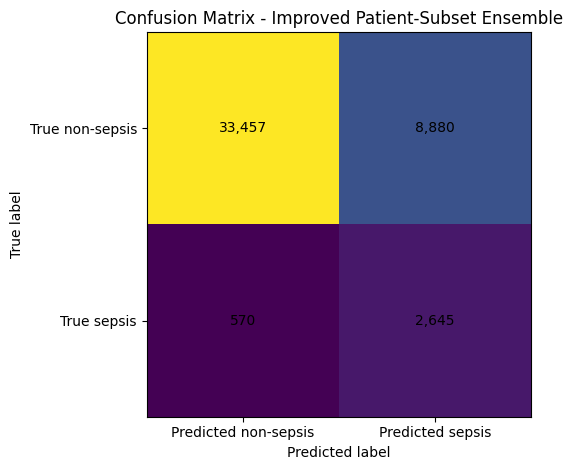

Saved: /kaggle/working/figure_confusion_matrix_improved_pse.png


In [18]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.8))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted non-sepsis", "Predicted sepsis"])
ax.set_yticklabels(["True non-sepsis", "True sepsis"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - Improved Patient-Subset Ensemble")

plt.tight_layout()

fig_path = "/kaggle/working/figure_confusion_matrix_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Precision-Recall curve

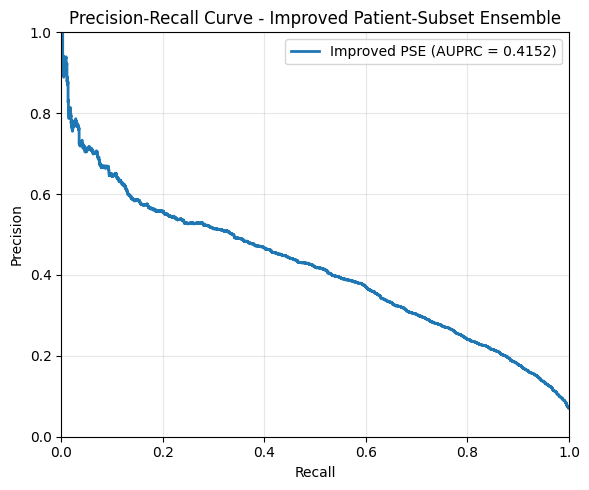

Saved: /kaggle/working/figure_pr_curve_improved_pse.png


In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, ensemble_test_prob)
auprc = average_precision_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Improved PSE (AUPRC = {auprc:.4f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_pr_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### ROC curve

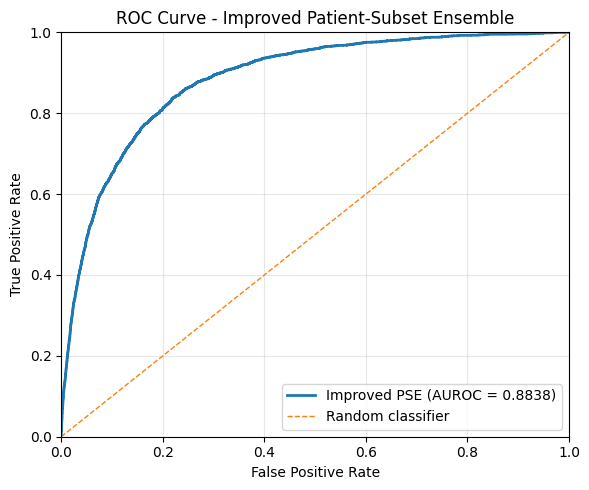

Saved: /kaggle/working/figure_roc_curve_improved_pse.png


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, ensemble_test_prob)
auroc = roc_auc_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Improved PSE (AUROC = {auroc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_roc_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Error analysis inputs for the main ensemble model

In [21]:
import numpy as np
import pandas as pd

# ===== Build sequence-level prediction tables =====
df_val_pred = pd.DataFrame({
    "row_id": np.arange(len(y_val)),
    "patient_id": id_val,
    "y_true": y_val.astype(int),
    "y_prob": ensemble_val_prob,
})

df_test_pred = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
})

df_val_pred["y_pred"] = (df_val_pred["y_prob"] >= best_threshold).astype(int)
df_test_pred["y_pred"] = (df_test_pred["y_prob"] >= best_threshold).astype(int)

def error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    else:
        return "TN"

df_val_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_val_pred["y_true"], df_val_pred["y_pred"])
]
df_test_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_test_pred["y_true"], df_test_pred["y_pred"])
]

# ===== Ensemble disagreement / uncertainty =====
df_val_pred["member_prob_std"] = val_probs_array.std(axis=0)
df_val_pred["member_prob_min"] = val_probs_array.min(axis=0)
df_val_pred["member_prob_max"] = val_probs_array.max(axis=0)

df_test_pred["member_prob_std"] = test_probs_array.std(axis=0)
df_test_pred["member_prob_min"] = test_probs_array.min(axis=0)
df_test_pred["member_prob_max"] = test_probs_array.max(axis=0)

print("Validation error types:")
print(df_val_pred["error_type"].value_counts())

print("\nTest error types:")
print(df_test_pred["error_type"].value_counts())

df_val_pred.to_csv("ensemble_val_predictions.csv", index=False)
df_test_pred.to_csv("ensemble_test_predictions.csv", index=False)

print("\nSaved:")
print("- ensemble_val_predictions.csv")
print("- ensemble_test_predictions.csv")

Validation error types:
error_type
TN    26490
FP     7314
TP     2238
FN      555
Name: count, dtype: int64

Test error types:
error_type
TN    33457
FP     8880
TP     2645
FN      570
Name: count, dtype: int64

Saved:
- ensemble_val_predictions.csv
- ensemble_test_predictions.csv


In [22]:
def summarize_error_groups(df):
    return (
        df.groupby("error_type")
          .agg(
              n=("row_id", "size"),
              mean_prob=("y_prob", "mean"),
              median_prob=("y_prob", "median"),
              mean_member_std=("member_prob_std", "mean"),
              n_patients=("patient_id", "nunique"),
          )
          .sort_values("n", ascending=False)
    )

print("Validation summary:")
display(summarize_error_groups(df_val_pred))

print("\nTest summary:")
display(summarize_error_groups(df_test_pred))

Validation summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,26490,0.072091,0.030370,0.062393,6084
FP,7314,0.624042,0.611415,0.154677,2259
TP,2238,0.764796,0.833227,0.106779,371
FN,555,0.149805,0.140697,0.123655,146



Test summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,33457,0.071921,0.031065,0.062192,7635
FP,8880,0.627380,0.611768,0.152659,2770
TP,2645,0.779368,0.848963,0.100226,448
FN,570,0.164967,0.161245,0.135607,163


### Metadata

In [23]:
meta_train = pd.read_csv('/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val/meta_train.csv')
meta_val = pd.read_csv('/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val/meta_val.csv')
meta_test = pd.read_csv('/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val/meta_test.csv')

# ===== Merge on row_id =====
df_val_analysis = df_val_pred.merge(
    meta_val,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

df_test_analysis = df_test_pred.merge(
    meta_test,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

# ===== Correct merge checks =====
assert len(df_val_analysis) == len(df_val_pred)
assert len(df_test_analysis) == len(df_test_pred)

assert (df_val_analysis['patient_id_pred'].values == df_val_analysis['patient_id_meta'].values).all()
assert (df_test_analysis['patient_id_pred'].values == df_test_analysis['patient_id_meta'].values).all()

assert (df_val_analysis['y_true_pred'].values == df_val_analysis['y_true_meta'].values).all()
assert (df_test_analysis['y_true_pred'].values == df_test_analysis['y_true_meta'].values).all()

# Chỉ kiểm tra các cột metadata KHÔNG được phép thiếu
assert df_val_analysis['window_end_hour'].isna().sum() == 0
assert df_test_analysis['window_end_hour'].isna().sum() == 0

assert df_val_analysis['raw_missing_rate_window'].isna().sum() == 0
assert df_test_analysis['raw_missing_rate_window'].isna().sum() == 0

# ===== Rename columns back to clean names =====
df_val_analysis = df_val_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

df_test_analysis = df_test_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

print("df_val_analysis:", df_val_analysis.shape)
print("df_test_analysis:", df_test_analysis.shape)

print("\nMissing check:")
print("VAL  - window_end_hour:", df_val_analysis['window_end_hour'].isna().sum())
print("VAL  - raw_missing_rate_window:", df_val_analysis['raw_missing_rate_window'].isna().sum())
print("VAL  - last_HR_raw:", df_val_analysis['last_HR_raw'].isna().sum())

print("TEST - window_end_hour:", df_test_analysis['window_end_hour'].isna().sum())
print("TEST - raw_missing_rate_window:", df_test_analysis['raw_missing_rate_window'].isna().sum())
print("TEST - last_HR_raw:", df_test_analysis['last_HR_raw'].isna().sum())

display(df_val_analysis.head())
display(df_test_analysis.head())

print("Merge check passed.")

df_val_analysis: (36597, 32)
df_test_analysis: (45552, 32)

Missing check:
VAL  - window_end_hour: 0
VAL  - raw_missing_rate_window: 0
VAL  - last_HR_raw: 3034
TEST - window_end_hour: 0
TEST - raw_missing_rate_window: 0
TEST - last_HR_raw: 3694


,row_id,patient_id,y_true,y_prob,y_pred,error_type,member_prob_std,member_prob_min,member_prob_max,seq_index_within_patient,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,6,0,0.301103,0,TN,0.168645,0.077844,0.566654,0,...,95.0,NaN,-26.5,-7.0,-27.50,-18.0,9,9,9,9
1,1,6,0,0.664741,1,FP,0.219065,0.324352,0.938382,1,...,94.5,NaN,-0.5,-10.0,3.75,8.5,10,10,10,10
2,2,6,0,0.706070,1,FP,0.050643,0.647368,0.788495,2,...,95.0,NaN,-2.0,7.5,-7.00,-7.0,10,10,10,10
3,3,6,0,0.813841,1,FP,0.121968,0.621491,0.974845,3,...,95.0,NaN,-8.0,-7.0,4.00,8.0,10,10,10,10
4,4,6,0,0.532276,1,FP,0.147733,0.352503,0.753256,4,...,95.0,NaN,-10.0,-11.0,16.00,8.0,10,10,10,10


,row_id,patient_id,y_true,y_prob,y_pred,error_type,member_prob_std,member_prob_min,member_prob_max,seq_index_within_patient,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,1,0,0.155523,0,TN,0.112497,0.019923,0.330744,0,...,95.0,36.11,-3.0,-6.5,19.0,12.0,9,9,9,9
1,1,1,0,0.130927,0,TN,0.134962,0.021378,0.375006,1,...,94.0,NaN,0.0,-3.0,-19.0,-10.0,10,10,10,10
2,2,1,0,0.076426,0,TN,0.083970,0.007000,0.236742,2,...,97.0,36.11,-1.0,6.0,-25.0,-14.0,10,7,4,10
3,3,4,0,0.009576,0,TN,0.005047,0.001845,0.015930,0,...,98.0,NaN,-21.0,-2.5,-16.5,-17.5,9,9,9,8
4,4,4,0,0.009400,0,TN,0.004638,0.003711,0.016011,1,...,99.0,36.94,3.0,-4.0,-13.0,-7.0,10,10,10,10


Merge check passed.


In [24]:
# ===== Fixed missingness cutoff from TRAIN =====
missing_cutoff = meta_train['raw_missing_rate_window'].median()
print("missing_cutoff from train =", missing_cutoff)

missing_cutoff from train = 0.1666666666666666


In [25]:
# ===== Create clinically meaningful subgroups =====

for df in [df_val_analysis, df_test_analysis]:
    df['hr_high'] = (df['last_HR_raw'] >= 100).astype(int)
    df['resp_high'] = (df['last_Resp_raw'] >= 22).astype(int)
    df['sbp_low'] = (df['last_SBP_raw'] <= 100).astype(int)
    df['map_low'] = (df['last_MAP_raw'] < 65).astype(int)

    # Dùng cutoff cố định từ TRAIN
    df['missing_high'] = (df['raw_missing_rate_window'] >= missing_cutoff).astype(int)

    df['delta_hr_up'] = (df['delta_HR_raw'] > 0).astype(int)
    df['delta_resp_up'] = (df['delta_Resp_raw'] > 0).astype(int)
    df['delta_sbp_down'] = (df['delta_SBP_raw'] < 0).astype(int)
    df['delta_map_down'] = (df['delta_MAP_raw'] < 0).astype(int)

    df['eda_pattern_strong'] = (
        (df['delta_hr_up'] == 1) &
        (df['delta_resp_up'] == 1) &
        (
            (df['delta_sbp_down'] == 1) |
            (df['delta_map_down'] == 1)
        )
    ).astype(int)

print("Done creating subgroup flags.")
print("Using fixed missing_cutoff from train:", missing_cutoff)

Done creating subgroup flags.
Using fixed missing_cutoff from train: 0.1666666666666666


In [26]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score

def subgroup_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        y_true = sub['y_true'].values
        y_prob = sub['y_prob'].values
        y_pred = sub['y_pred'].values

        if len(np.unique(y_true)) < 2:
            auprc = np.nan
        else:
            auprc = average_precision_score(y_true, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append({
            'group': group_value,
            'n': len(sub),
            'positive_rate': sub['y_true'].mean(),
            'AUPRC': auprc,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'f1': f1,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'TN': tn,
            'mean_prob': sub['y_prob'].mean(),
            'mean_member_std': sub['member_prob_std'].mean()
        })

    return pd.DataFrame(rows).sort_values('group')

In [27]:
# ===== First subgroup analyses =====

report_pattern_val = subgroup_report(df_val_analysis, 'eda_pattern_strong')
report_pattern_test = subgroup_report(df_test_analysis, 'eda_pattern_strong')

report_missing_val = subgroup_report(df_val_analysis, 'missing_high')
report_missing_test = subgroup_report(df_test_analysis, 'missing_high')

report_hr_val = subgroup_report(df_val_analysis, 'hr_high')
report_hr_test = subgroup_report(df_test_analysis, 'hr_high')

print("Validation - EDA pattern strong")
display(report_pattern_val)

print("Test - EDA pattern strong")
display(report_pattern_test)

print("Validation - Missing high")
display(report_missing_val)

print("Test - Missing high")
display(report_missing_test)

print("Validation - HR high")
display(report_hr_val)

print("Test - HR high")
display(report_hr_test)

Validation - EDA pattern strong


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,32041,0.073624,0.384884,0.796100,0.783808,0.226401,0.352544,6417,481,1878,23265,0.223862,0.084283
1,1,4556,0.095259,0.448083,0.829493,0.782387,0.286396,0.425784,897,74,360,3225,0.240551,0.085865


Test - EDA pattern strong


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,39956,0.068275,0.416325,0.823314,0.791420,0.224353,0.352618,7765,482,2246,29463,0.220220,0.082670
1,1,5596,0.087026,0.412484,0.819302,0.781758,0.263540,0.398801,1115,88,399,3994,0.238341,0.084987


Validation - Missing high


...

,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,21859,0.078183,0.411218,0.840843,0.756228,0.226335,0.356664,4912,272,1437,15238,0.250288,0.089489
1,1,23693,0.063563,0.421489,0.802125,0.821157,0.233385,0.361568,3968,298,1208,18219,0.196759,0.076926


Validation - HR high


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,30182,0.066497,0.364490,0.794220,0.803691,0.223719,0.349102,5531,413,1594,22644,0.208048,0.079617
1,1,6415,0.122525,0.467153,0.819338,0.683247,0.265348,0.400871,1783,142,644,3846,0.310115,0.107360


Test - HR high


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,37614,0.061759,0.387628,0.807146,0.811453,0.219838,0.345558,6654,448,1875,28637,0.202932,0.077976
1,1,7938,0.112371,0.480182,0.863229,0.684076,0.257009,0.396091,2226,122,770,4820,0.314910,0.106544


In [28]:
print("Current validation error counts:")
print(df_val_analysis['error_type'].value_counts())

print("\nCurrent test error counts:")
print(df_test_analysis['error_type'].value_counts())

Current validation error counts:
error_type
TN    26490
FP     7314
TP     2238
FN      555
Name: count, dtype: int64

Current test error counts:
error_type
TN    33457
FP     8880
TP     2645
FN      570
Name: count, dtype: int64


In [29]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    df_test_analysis['y_true'],
    df_test_analysis['y_pred'],
    labels=[0, 1]
).ravel()

print("TN, FP, FN, TP =", tn, fp, fn, tp)

TN, FP, FN, TP = 33457 8880 570 2645


### FN và FP theo subgroup.

In [30]:
def fn_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        pos = sub[sub['y_true'] == 1].copy()   # chỉ xét các cửa sổ thật sự positive
        n_pos = len(pos)

        fn = (pos['error_type'] == 'FN').sum()
        tp = (pos['error_type'] == 'TP').sum()

        fn_rate = fn / n_pos if n_pos > 0 else np.nan
        tp_rate = tp / n_pos if n_pos > 0 else np.nan

        fn_sub = pos[pos['error_type'] == 'FN']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_positive': n_pos,
            'FN': fn,
            'TP': tp,
            'FN_rate_within_positive': fn_rate,
            'TP_rate_within_positive': tp_rate,
            'mean_prob_positive': pos['y_prob'].mean() if n_pos > 0 else np.nan,
            'mean_prob_FN': fn_sub['y_prob'].mean() if len(fn_sub) > 0 else np.nan,
            'mean_member_std_FN': fn_sub['member_prob_std'].mean() if len(fn_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [31]:
def fp_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        neg = sub[sub['y_true'] == 0].copy()   # chỉ xét các cửa sổ thật sự negative
        n_neg = len(neg)

        fp = (neg['error_type'] == 'FP').sum()
        tn = (neg['error_type'] == 'TN').sum()

        fp_rate = fp / n_neg if n_neg > 0 else np.nan
        tn_rate = tn / n_neg if n_neg > 0 else np.nan

        fp_sub = neg[neg['error_type'] == 'FP']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_negative': n_neg,
            'FP': fp,
            'TN': tn,
            'FP_rate_within_negative': fp_rate,
            'TN_rate_within_negative': tn_rate,
            'mean_prob_negative': neg['y_prob'].mean() if n_neg > 0 else np.nan,
            'mean_prob_FP': fp_sub['y_prob'].mean() if len(fp_sub) > 0 else np.nan,
            'mean_member_std_FP': fp_sub['member_prob_std'].mean() if len(fp_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [32]:
# ===== FN reports on test =====
fn_pattern_test = fn_report(df_test_analysis, 'eda_pattern_strong')
fn_missing_test = fn_report(df_test_analysis, 'missing_high')
fn_hr_test = fn_report(df_test_analysis, 'hr_high')
fn_resp_test = fn_report(df_test_analysis, 'resp_high')
fn_sbp_test = fn_report(df_test_analysis, 'sbp_low')
fn_map_test = fn_report(df_test_analysis, 'map_low')

print("Test - FN by EDA pattern strong")
display(fn_pattern_test)

print("Test - FN by Missing high")
display(fn_missing_test)

print("Test - FN by HR high")
display(fn_hr_test)

print("Test - FN by Resp high")
display(fn_resp_test)

print("Test - FN by SBP low")
display(fn_sbp_test)

print("Test - FN by MAP low")
display(fn_map_test)

Test - FN by EDA pattern strong


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,39956,2728,482,2246,0.176686,0.823314,0.672812,0.169777,0.140211
1,1,5596,487,88,399,0.180698,0.819302,0.657145,0.138625,0.110384


Test - FN by Missing high


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,21859,1709,272,1437,0.159157,0.840843,0.687500,0.182767,0.151905
1,1,23693,1506,298,1208,0.197875,0.802125,0.651078,0.148720,0.120730


Test - FN by HR high


...

,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,35296,2088,431,1657,0.206418,0.793582,0.643292,0.159177,0.130527
1,1,10256,1127,139,988,0.123336,0.876664,0.720734,0.182922,0.151356


Test - FN by SBP low


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,39435,2661,481,2180,0.180759,0.819241,0.669143,0.165652,0.137561
1,1,6117,554,89,465,0.160650,0.839350,0.676664,0.161268,0.125042


Test - FN by MAP low


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,40912,2759,507,2252,0.183762,0.816238,0.664306,0.161742,0.133882
1,1,4640,456,63,393,0.138158,0.861842,0.707544,0.190921,0.149483


In [33]:
# ===== FP reports on test =====
fp_pattern_test = fp_report(df_test_analysis, 'eda_pattern_strong')
fp_missing_test = fp_report(df_test_analysis, 'missing_high')
fp_hr_test = fp_report(df_test_analysis, 'hr_high')
fp_resp_test = fp_report(df_test_analysis, 'resp_high')
fp_sbp_test = fp_report(df_test_analysis, 'sbp_low')
fp_map_test = fp_report(df_test_analysis, 'map_low')

print("Test - FP by EDA pattern strong")
display(fp_pattern_test)

print("Test - FP by Missing high")
display(fp_missing_test)

print("Test - FP by HR high")
display(fp_hr_test)

print("Test - FP by Resp high")
display(fp_resp_test)

print("Test - FP by SBP low")
display(fp_sbp_test)

print("Test - FP by MAP low")
display(fp_map_test)

Test - FP by EDA pattern strong


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,39956,37228,7765,29463,0.208580,0.791420,0.187054,0.625487,0.153258
1,1,5596,5109,1115,3994,0.218242,0.781758,0.198420,0.640561,0.148488


Test - FP by Missing high


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,21859,20150,4912,15238,0.243772,0.756228,0.213206,0.639634,0.147952
1,1,23693,22187,3968,18219,0.178843,0.821157,0.165921,0.612211,0.158486


Test - FP by HR high


...

,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,35296,33208,6137,27071,0.184805,0.815195,0.170008,0.617522,0.156490
1,1,10256,9129,2743,6386,0.300471,0.699529,0.255425,0.649436,0.144088


Test - FP by SBP low


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,39435,36774,7350,29424,0.199869,0.800131,0.181763,0.629564,0.150857
1,1,6117,5563,1530,4033,0.275031,0.724969,0.232473,0.616890,0.161314


Test - FP by MAP low


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,40912,38153,7676,30477,0.201190,0.798810,0.182316,0.631191,0.151818
1,1,4640,4184,1204,2980,0.287763,0.712237,0.244140,0.603084,0.158022


## Case studies of the main model at the window level

In [34]:
# ===== Select a representative TP window =====

tp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'TP') &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1)
    )
].copy()

tp_candidates = tp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

tp_case = tp_candidates.iloc[0]

display(pd.DataFrame([tp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std',
    'window_start_hour', 'window_end_hour', 'hours_to_onset',
    'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,hours_to_onset,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
4944,4208,4944,TP,1,1,0.978381,0.009458,1,10,-7.0,...,132.0,27.0,NaN,94.0,1,1,0,0,1,0


In [35]:
# ===== Select a representative FN window =====

fn_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FN') &
    (df_test_analysis['missing_high'] == 1)
].copy()

# near-miss FN: trong các FN thiếu dữ liệu, chọn ca có xác suất cao nhất
fn_candidates = fn_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

fn_case = fn_candidates.iloc[0]

display(pd.DataFrame([fn_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std',
    'window_start_hour', 'window_end_hour', 'hours_to_onset',
    'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,hours_to_onset,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
43751,38721,43751,FN,1,0,0.337441,0.273496,32,41,-7.0,...,108.0,25.0,122.0,93.0,1,1,0,0,1,0


In [36]:
# ===== Select a representative FP window =====

fp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FP') &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1)
    )
].copy()

fp_candidates = fp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

fp_case = fp_candidates.iloc[0]

display(pd.DataFrame([fp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std',
    'window_start_hour', 'window_end_hour', 'hours_to_onset',
    'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,hours_to_onset,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
27491,24384,27491,FP,0,1,0.96403,0.014834,132,141,157.0,...,97.5,22.0,78.0,73.5,0,1,1,0,0,0


In [37]:
# ===== Summary of selected case windows =====

selected_cases = pd.DataFrame([
    tp_case,
    fn_case,
    fp_case
]).copy()

selected_cases.index = ['TP_case', 'FN_case', 'FP_case']

display(selected_cases[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std',
    'window_start_hour', 'window_end_hour', 'hours_to_onset',
    'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,hours_to_onset,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
TP_case,4208,4944,TP,1,1,0.978381,0.009458,1,10,-7.0,...,132.0,27.0,NaN,94.0,1,1,0,0,1,0
FN_case,38721,43751,FN,1,0,0.337441,0.273496,32,41,-7.0,...,108.0,25.0,122.0,93.0,1,1,0,0,1,0
FP_case,24384,27491,FP,0,1,0.964030,0.014834,132,141,157.0,...,97.5,22.0,78.0,73.5,0,1,1,0,0,0


In [38]:
# ===== Select a representative TP window near onset =====

tp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'TP') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

tp_candidates = tp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of TP candidates:", len(tp_candidates))

tp_case = tp_candidates.iloc[0]

display(pd.DataFrame([tp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of TP candidates: 39


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
30228,26846,30228,TP,1,1,0.936255,0.026055,120,129,129.0,...,74.0,25.0,156.0,102.0,0,1,0,0,0,0


In [39]:
# ===== Select a representative FN window near onset =====

fn_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FN') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6)
].copy()

# ưu tiên failure mode missingness; nếu có pattern EDA thì càng hay
fn_candidates = fn_candidates.sort_values(
    ['missing_high', 'eda_pattern_strong', 'y_prob', 'member_prob_std'],
    ascending=[False, False, False, True]
)

print("Number of FN candidates:", len(fn_candidates))

fn_case = fn_candidates.iloc[0]

display(pd.DataFrame([fn_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of FN candidates: 20


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
3449,2879,3449,FN,1,0,0.016428,0.016397,12,21,21.0,...,110.0,26.0,146.0,112.0,1,1,0,0,1,1


In [40]:
# ===== Select a representative FP window on a non-sepsis patient =====

fp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FP') &
    (df_test_analysis['is_sepsis_patient'] == 0) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

fp_candidates = fp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of FP candidates:", len(fp_candidates))

fp_case = fp_candidates.iloc[0]

display(pd.DataFrame([fp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of FP candidates: 3550


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
39747,35284,39747,FP,0,1,0.96053,0.024943,6,15,NaN,...,121.0,25.0,83.0,78.0,1,1,1,0,1,1


In [41]:
# ===== Summary of the refined case-study set =====

selected_cases = pd.DataFrame([
    tp_case,
    fn_case,
    fp_case
]).copy()

selected_cases.index = ['TP_case', 'FN_case', 'FP_case']

display(selected_cases[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
TP_case,26846,30228,TP,1,1,0.936255,0.026055,120,129,129.0,...,74.0,25.0,156.0,102.0,0,1,0,0,0,0
FN_case,2879,3449,FN,1,0,0.016428,0.016397,12,21,21.0,...,110.0,26.0,146.0,112.0,1,1,0,0,1,1
FP_case,35284,39747,FP,0,1,0.960530,0.024943,6,15,NaN,...,121.0,25.0,83.0,78.0,1,1,1,0,1,1


### Subgroup performance

In [42]:
from sklearn.metrics import average_precision_score

def compute_metrics(df):
    y_true = df['y_true']
    y_pred = df['y_pred']
    y_prob = df['y_prob']
    
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    
    try:
        auprc = average_precision_score(y_true, y_prob)
    except:
        auprc = np.nan
    
    return pd.Series({
        'n': len(df),
        'positive_rate': y_true.mean(),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'AUPRC': auprc,
        'mean_pred_prob': y_prob.mean()
    })


subgroups = [
    'hr_high',
    'resp_high',
    'sbp_low',
    'map_low',
    'missing_high',
    'eda_pattern_strong'
]

rows = []

for sg in subgroups:
    for val in [0, 1]:
        df_sub = df_test_analysis[df_test_analysis[sg] == val]
        
        metrics = compute_metrics(df_sub)
        metrics['subgroup'] = sg
        metrics['value'] = val
        
        rows.append(metrics)

df_subgroup_table = pd.DataFrame(rows)

# sắp xếp lại cho đẹp
df_subgroup_table = df_subgroup_table[
    ['subgroup', 'value', 'n', 'positive_rate', 'sensitivity', 'specificity', 'AUPRC', 'mean_pred_prob']
].sort_values(['subgroup', 'value'])

display(df_subgroup_table)

,subgroup,value,n,positive_rate,sensitivity,specificity,AUPRC,mean_pred_prob
10,eda_pattern_strong,0,39956.0,0.068275,0.823314,0.791420,0.416325,0.220220
11,eda_pattern_strong,1,5596.0,0.087026,0.819302,0.781758,0.412484,0.238341
0,hr_high,0,37614.0,0.061759,0.807146,0.811453,0.387628,0.202932
1,hr_high,1,7938.0,0.112371,0.863229,0.684076,0.480182,0.314910
6,map_low,0,40912.0,0.067437,0.816238,0.798810,0.399130,0.214820
7,map_low,1,4640.0,0.098276,0.861842,0.712237,0.515653,0.289681
8,missing_high,0,21859.0,0.078183,0.840843,0.756228,0.411218,0.250288
9,missing_high,1,23693.0,0.063563,0.802125,0.821157,0.421489,0.196759
2,resp_high,0,35296.0,0.059157,0.793582,0.815195,0.388251,0.198006
3,resp_high,1,10256.0,0.109887,0.876664,0.699529,0.463040,0.306556


In [43]:
df_subgroup_table.to_csv('/kaggle/working/subgroup_performance_table.csv', index=False)

### FN/FP theo missingness

In [44]:
rows = []

for val in [0, 1]:
    df_sub = df_test_analysis[df_test_analysis['missing_high'] == val]
    
    # positive group
    df_pos = df_sub[df_sub['y_true'] == 1]
    fn_rate = ((df_pos['y_pred'] == 0).sum() / len(df_pos)) if len(df_pos) > 0 else np.nan
    
    # negative group
    df_neg = df_sub[df_sub['y_true'] == 0]
    fp_rate = ((df_neg['y_pred'] == 1).sum() / len(df_neg)) if len(df_neg) > 0 else np.nan
    
    mean_prob = df_sub['y_prob'].mean()
    
    rows.append({
        'missing_high': val,
        'n': len(df_sub),
        'FN_rate_within_positive': fn_rate,
        'FP_rate_within_negative': fp_rate,
        'mean_pred_prob': mean_prob
    })

df_missing_table = pd.DataFrame(rows)

display(df_missing_table)

,missing_high,n,FN_rate_within_positive,FP_rate_within_negative,mean_pred_prob
0,0,21859,0.159157,0.243772,0.250288
1,1,23693,0.197875,0.178843,0.196759


In [45]:
df_missing_table.to_csv('/kaggle/working/missingness_error_table.csv', index=False)